In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

os.environ["KERAS_BACKEND"] = "torch"
import keras as k
from keras.layers import LSTM, Dense
from keras.models import Sequential

k.backend.backend()


'torch'

In [2]:
df = pd.read_csv("../apple_share_price.csv")
df_n=df[['Date','Open','Close']]

In [3]:
df_n['Date']=pd.to_datetime(df_n['Date'].apply(lambda x: x.split(" ")[0]))

/tmp/ipykernel_7587/230016098.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_n['Date']=pd.to_datetime(df_n['Date'].apply(lambda x: x.split(" ")[0]))
/tmp/ipykernel_7587/230016098.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_n['Date']=pd.to_datetime(df_n['Date'].apply(lambda x: x.split(" ")[0]))


In [8]:
df_n.set_index('Date',drop=True,inplace=True)

/tmp/ipykernel_7587/2107194740.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fg.show()


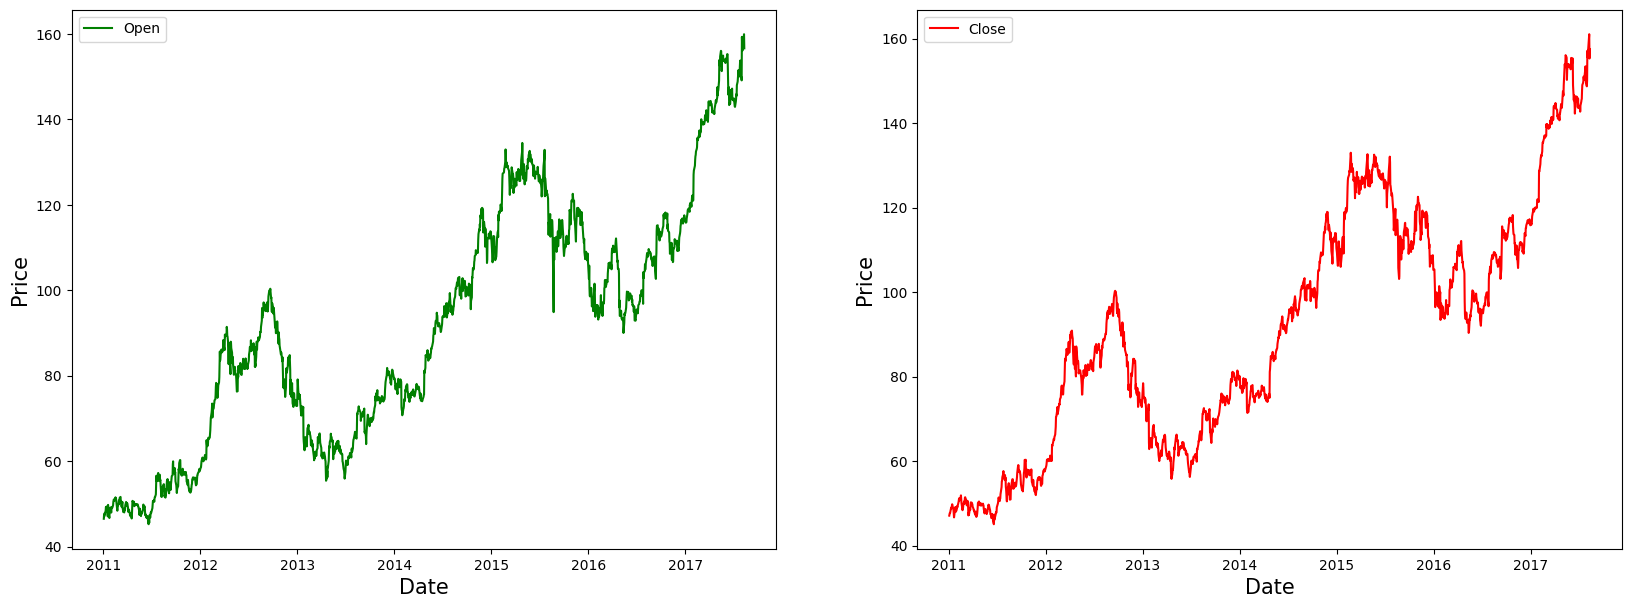

In [10]:
import numpy as np
import matplotlib.pyplot as plt
fg, ax =plt.subplots(1,2,figsize=(20,7))
ax[0].plot(df_n['Open'],label='Open',color='green')
ax[0].set_xlabel('Date',size=15)
ax[0].set_ylabel('Price',size=15)
ax[0].legend()

ax[1].plot(df_n['Close'],label='Close',color='red')
ax[1].set_xlabel('Date',size=15)
ax[1].set_ylabel('Price',size=15)
ax[1].legend()

fg.show()

In [11]:
from sklearn.preprocessing import MinMaxScaler
MMS = MinMaxScaler()
df_n[df_n.columns] = MMS.fit_transform(df_n)

/tmp/ipykernel_7587/1343166756.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_n[df_n.columns] = MMS.fit_transform(df_n)


In [12]:
df_n.shape

(1664, 2)

In [13]:
training_size = round(len(df_n) * 0.80) # Selecting 80 % for training and 20 % for testing
training_size

1331

In [14]:
train_data = df_n[:training_size]
test_data  = df_n[training_size:]

train_data.shape, test_data.shape

((1331, 2), (333, 2))

In [15]:
# Function to create sequence of data for training and testing

def create_sequence(dataset):
                sequences = []
                labels = []
                start_idx = 0
                for stop_idx in range(50,len(dataset)):                   # Selecting 50 rows at a time
                    sequences.append(dataset.iloc[start_idx:stop_idx])
                    labels.append(dataset.iloc[stop_idx])
                    start_idx += 1
                return (np.array(sequences),np.array(labels))


In [16]:
train_seq, train_label = create_sequence(train_data)
test_seq, test_label = create_sequence(test_data)

In [17]:
train_seq.shape, train_label.shape, test_seq.shape, test_label.shape

((1281, 50, 2), (1281, 2), (283, 50, 2), (283, 2))

In [18]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Bidirectional

In [19]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape = (train_seq.shape[1], train_seq.shape[2])))

model.add(Dropout(0.1))
model.add(LSTM(units=50))

model.add(Dense(2))

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_absolute_error'])

model.summary()

/workspaces/ml-stuff/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 50)         │        10,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,902 (120.71 KB)

 Trainable params: 30,902 (120.71 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.fit(train_seq, train_label, epochs=80,validation_data=(test_seq, test_label), verbose=1)

Epoch 1/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 216ms/step - loss: 0.0977 - mean_absolute_error: 0.2291 - val_loss: 0.0053 - val_mean_absolute_error: 0.0708
Epoch 2/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 206ms/step - loss: 0.0026 - mean_absolute_error: 0.0388 - val_loss: 0.0011 - val_mean_absolute_error: 0.0296
Epoch 3/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 216ms/step - loss: 0.0011 - mean_absolute_error: 0.0265 - val_loss: 8.4918e-04 - val_mean_absolute_error: 0.0252
Epoch 4/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 196ms/step - loss: 0.0011 - mean_absolute_error: 0.0261 - val_loss: 7.8199e-04 - val_mean_absolute_error: 0.0242
Epoch 5/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 208ms/step - loss: 0.0012 - mean_absolute_error: 0.0266 - val_loss: 7.8877e-04 - val_mean_absolute_error: 0.0243
Epoch 6/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 221ms/step - loss: 0.0011 - mean_absolute_error: 0.0260 - val_loss: 7.0672e-04 - val_mean_absolute_error: 0.0229
Epoch 7/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 234ms/step - loss: 0.0012 - mean_absolute_

In [21]:
test_predicted = model.predict(test_seq)
test_predicted[:5]

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step


array([[0.23013937, 0.22844051],
       [0.22999234, 0.22821517],
       [0.23097035, 0.22932838],
       [0.2302405 , 0.22885628],
       [0.22614367, 0.22500257]], dtype=float32)

In [22]:
test_inverse_predicted = MMS.inverse_transform(test_predicted) # Inversing scaling on predicted data
test_inverse_predicted[:5]

array([[71.627785, 71.551384],
       [71.61092 , 71.525246],
       [71.72306 , 71.65438 ],
       [71.63937 , 71.59962 ],
       [71.16963 , 71.15254 ]], dtype=float32)

In [26]:
# Merging actual and predicted data for better visualization

gs_slic_data = pd.concat([df_n.iloc[-283:].copy(),pd.DataFrame(test_inverse_predicted,columns=['open_predicted','close_predicted'],index=df_n.iloc[-283:].index)], axis=1)

In [27]:
gs_slic_data[['open','close']] = MMS.inverse_transform(gs_slic_data[['Open','Close']]) # Inverse scaling

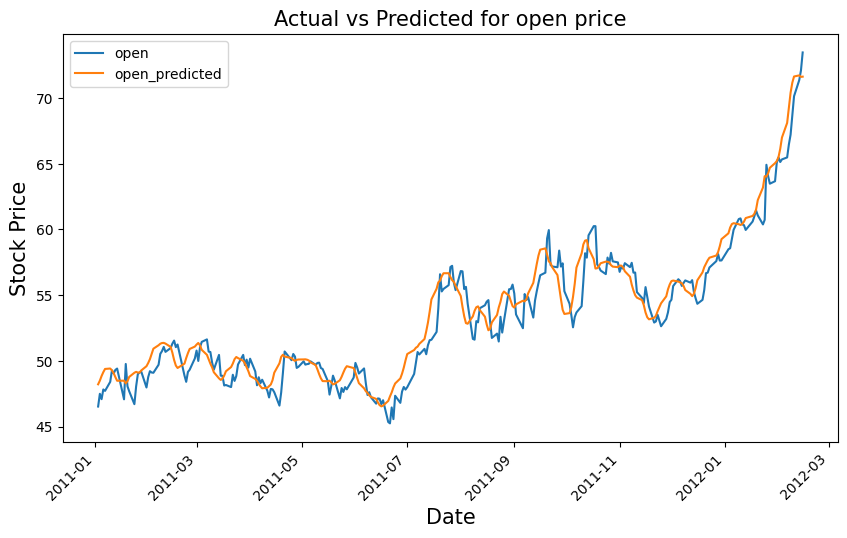

In [29]:
gs_slic_data[['open','open_predicted']].plot(figsize=(10,6))
plt.xticks(rotation=45)
plt.xlabel('Date',size=15)
plt.ylabel('Stock Price',size=15)
plt.title('Actual vs Predicted for open price',size=15)
plt.show()

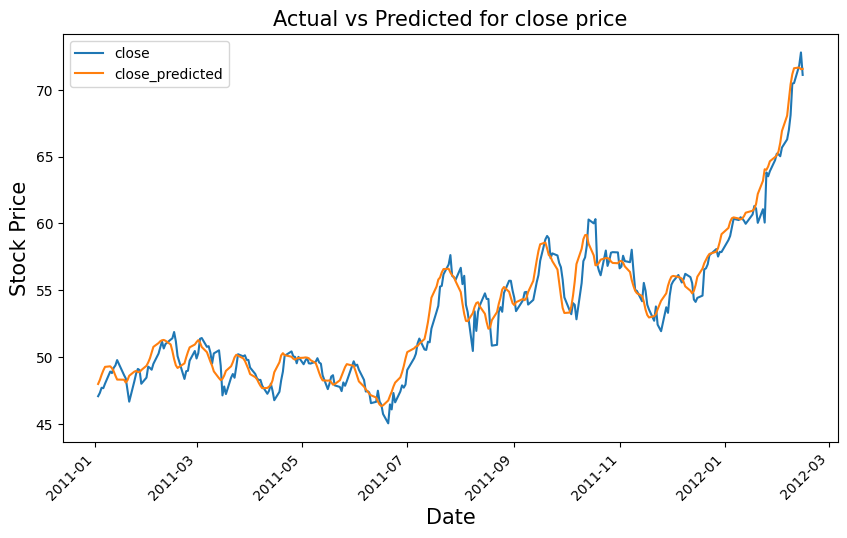

In [30]:
gs_slic_data[['close','close_predicted']].plot(figsize=(10,6))
plt.xticks(rotation=45)
plt.xlabel('Date',size=15)
plt.ylabel('Stock Price',size=15)
plt.title('Actual vs Predicted for close price',size=15)
plt.show()

In [31]:
# Creating a dataframe and adding 10 days to existing index

gs_slic_data = gs_slic_data.append(pd.DataFrame(columns=gs_slic_data.columns,index=pd.date_range(start=gs_slic_data.index[-1], periods=11, freq='D', closed='right')))


AttributeError: 'DataFrame' object has no attribute 'append'

In [ ]:
gs_slic_data['2021-06-09	':'2021-06-16']

In [40]:
upcoming_prediction = pd.DataFrame(columns=['open','close'],index=gs_slic_data.index)
upcoming_prediction.index=pd.to_datetime(upcoming_prediction.index)

In [ ]:
curr_seq = test_seq[-1:]
for i in range(-10,0):
    up_pred = model.predict(curr_seq)
    upcoming_prediction.iloc[i] = up_pred
    curr_seq = np.append(curr_seq[0][1:],up_pred,axis=0)
    curr_seq = curr_seq.reshape(test_seq[-1:].shape)


In [42]:
upcoming_prediction[['open','close']] = MMS.inverse_transform(upcoming_prediction[['open','close']])

In [ ]:
fg,ax=plt.subplots(figsize=(10,5))
ax.plot(gs_slic_data.loc['2021-04-01':,'open'],label='Current Open Price')
ax.plot(upcoming_prediction.loc['2021-04-01':,'open'],label='Upcoming Open Price')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.set_xlabel('Date',size=15)
ax.set_ylabel('Stock Price',size=15)
ax.set_title('Upcoming Open price prediction',size=15)
ax.legend()
fg.show()

In [ ]:
fg,ax=plt.subplots(figsize=(10,5))
ax.plot(gs_slic_data.loc['2021-04-01':,'close'],label='Current close Price')
ax.plot(upcoming_prediction.loc['2021-04-01':,'close'],label='Upcoming close Price')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.set_xlabel('Date',size=15)
ax.set_ylabel('Stock Price',size=15)
ax.set_title('Upcoming close price prediction',size=15)
ax.legend()
fg.show()